**Gerekli Kütüphaneler**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

**CSV Dosyalarını Yükle**

In [3]:
normal_df = pd.read_csv("normal_radiomics.csv")
papilodem_df = pd.read_csv("papilodem_radiomics.csv")

**Target Oluştur**

In [4]:
normal_df["Target"] = 0
papilodem_df["Target"] = 1

**Veri Setlerini Birleştir**

In [5]:
df = pd.concat([normal_df, papilodem_df], axis=0).reset_index(drop=True)

**Genel Kontroller**

In [40]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Columns: 749 entries, PatientIndex to Target
dtypes: float64(676), int64(72), object(1)
memory usage: 5.5+ MB


**Sınıf Dağılımı**

In [7]:
print(df["Target"].value_counts())

Target
0    672
1    294
Name: count, dtype: int64


**Class Distribution Grafiği**

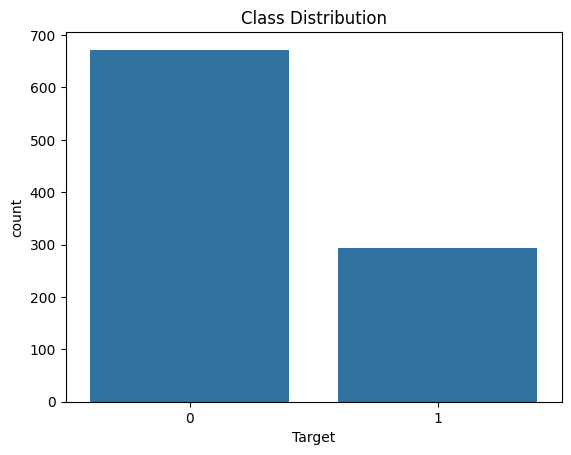

In [8]:
sns.countplot(x="Target", data=df)

plt.title("Class Distribution")
plt.show()

**Patient Sayısı**

In [9]:
print(df["PatientIndex"].nunique())

48


**Eksik Veri Kontrolü**

In [10]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print(missing_values)

Series([], dtype: int64)


**Sayısal Feature Ayrımı**

In [11]:
feature_columns = [
    col for col in df.columns
    if col not in ["PatientIndex", "SideStandard", "Target"]
]

print("Feature count:", len(feature_columns))

Feature count: 746


**Patient-Level Train / Validation / Test Split**

In [13]:
from sklearn.model_selection import GroupShuffleSplit

X = df.drop(columns=["Target"])
y = df["Target"]

groups = df["PatientIndex"]

# TRAIN+VAL / TEST

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train_val = X.iloc[train_val_idx]
X_test = X.iloc[test_idx]

y_train_val = y.iloc[train_val_idx]
y_test = y.iloc[test_idx]

groups_train_val = groups.iloc[train_val_idx]
groups_test = groups.iloc[test_idx]

# TRAIN / VALIDATION

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.125,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(
        X_train_val,
        y_train_val,
        groups_train_val
    )
)

X_train = X_train_val.iloc[train_idx]
X_val = X_train_val.iloc[val_idx]

y_train = y_train_val.iloc[train_idx]
y_val = y_train_val.iloc[val_idx]

groups_train = groups_train_val.iloc[train_idx]
groups_val = groups_train_val.iloc[val_idx]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (686, 748)
Validation: (98, 748)
Test: (182, 748)


**Patient Overlap Kontrolü**

In [14]:
train_patients = set(groups_train.unique())
val_patients = set(groups_val.unique())
test_patients = set(groups_test.unique())

print(train_patients.intersection(val_patients))
print(train_patients.intersection(test_patients))
print(val_patients.intersection(test_patients))

set()
set()
set()


**Median Imputation**

In [16]:
from sklearn.impute import SimpleImputer
import numpy as np

X_train_features = X_train[feature_columns].copy()
X_val_features = X_val[feature_columns].copy()
X_test_features = X_test[feature_columns].copy()

print("Train inf count:", np.isinf(X_train_features).sum().sum())
print("Validation inf count:", np.isinf(X_val_features).sum().sum())
print("Test inf count:", np.isinf(X_test_features).sum().sum())

X_train_features = X_train_features.replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features.replace([np.inf, -np.inf], np.nan)
X_test_features = X_test_features.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train_features)
X_val_imputed = imputer.transform(X_val_features)
X_test_imputed = imputer.transform(X_test_features)

print("Train imputed:", X_train_imputed.shape)
print("Validation imputed:", X_val_imputed.shape)
print("Test imputed:", X_test_imputed.shape)

print("Train NaN after imputation:", np.isnan(X_train_imputed).sum())
print("Validation NaN after imputation:", np.isnan(X_val_imputed).sum())
print("Test NaN after imputation:", np.isnan(X_test_imputed).sum())

Train inf count: 1
Validation inf count: 0
Test inf count: 0
Train imputed: (686, 746)
Validation imputed: (98, 746)
Test imputed: (182, 746)
Train NaN after imputation: 0
Validation NaN after imputation: 0
Test NaN after imputation: 0


**Low Variance Filtering**

In [17]:
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.01)

X_train_var = variance_selector.fit_transform(X_train_imputed)

X_val_var = variance_selector.transform(X_val_imputed)

X_test_var = variance_selector.transform(X_test_imputed)

print("Before variance filtering:", X_train_imputed.shape[1])
print("After variance filtering:", X_train_var.shape[1])

Before variance filtering: 746
After variance filtering: 418


Correlation **Filtering**

In [18]:
corr_matrix = pd.DataFrame(X_train_var).corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

X_train_corr = pd.DataFrame(X_train_var).drop(columns=to_drop)

X_val_corr = pd.DataFrame(X_val_var).drop(columns=to_drop)

X_test_corr = pd.DataFrame(X_test_var).drop(columns=to_drop)

print("Before correlation filtering:", X_train_var.shape[1])
print("After correlation filtering:", X_train_corr.shape[1])
print("Removed features:", len(to_drop))

Before correlation filtering: 418
After correlation filtering: 145
Removed features: 273


**Robust Scaling**

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_corr)

X_val_scaled = scaler.transform(X_val_corr)

X_test_scaled = scaler.transform(X_test_corr)

print("Train scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Train scaled shape: (686, 145)
Validation scaled shape: (98, 145)
Test scaled shape: (182, 145)


**MRMR Feature Selection**

In [20]:
from sklearn.feature_selection import mutual_info_classif

X_train_df = pd.DataFrame(X_train_scaled)
X_val_df = pd.DataFrame(X_val_scaled)
X_test_df = pd.DataFrame(X_test_scaled)

mi_scores = mutual_info_classif(
    X_train_df,
    y_train,
    random_state=42
)

mi_series = pd.Series(mi_scores)

top_k = 50

selected_features = mi_series.sort_values(
    ascending=False
).head(top_k).index

X_train_selected = X_train_df[selected_features]

X_val_selected = X_val_df[selected_features]

X_test_selected = X_test_df[selected_features]

print("Selected feature count:", len(selected_features))

print(selected_features.tolist()[:10])

Selected feature count: 50
[87, 25, 26, 88, 19, 82, 27, 1, 20, 128]


**Logistic Regression Modeli**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score
)

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_selected, y_train)

lr_preds = lr_model.predict(X_test_selected)
lr_probs = lr_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall:", recall_score(y_test, lr_preds))
print("F1-score:", f1_score(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, lr_preds))

Accuracy: 0.8461538461538461
Precision: 0.625
Recall: 0.8333333333333334
F1-score: 0.7142857142857143
ROC-AUC: 0.8782312925170067
Balanced Accuracy: 0.8416666666666667


**SVM**

In [22]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_selected, y_train)

svm_preds = svm_model.predict(X_test_selected)
svm_probs = svm_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, svm_preds))
print("Precision:", precision_score(y_test, svm_preds))
print("Recall:", recall_score(y_test, svm_preds))
print("F1-score:", f1_score(y_test, svm_preds))
print("ROC-AUC:", roc_auc_score(y_test, svm_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, svm_preds))

Accuracy: 0.8956043956043956
Precision: 0.7446808510638298
Recall: 0.8333333333333334
F1-score: 0.7865168539325843
ROC-AUC: 0.9056122448979592
Balanced Accuracy: 0.8738095238095238


**Random Forest**

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_selected, y_train)

rf_preds = rf_model.predict(X_test_selected)
rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-score:", f1_score(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds))

Accuracy: 0.8846153846153846
Precision: 0.7142857142857143
Recall: 0.8333333333333334
F1-score: 0.7692307692307693
ROC-AUC: 0.9132653061224489
Balanced Accuracy: 0.8666666666666667


**Extra Trees**

In [24]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

et_model.fit(X_train_selected, y_train)

et_preds = et_model.predict(X_test_selected)
et_probs = et_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, et_preds))
print("Precision:", precision_score(y_test, et_preds))
print("Recall:", recall_score(y_test, et_preds))
print("F1-score:", f1_score(y_test, et_preds))
print("ROC-AUC:", roc_auc_score(y_test, et_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds))

Accuracy: 0.8846153846153846
Precision: 0.7142857142857143
Recall: 0.8333333333333334
F1-score: 0.7692307692307693
ROC-AUC: 0.9201530612244897
Balanced Accuracy: 0.8666666666666667


**Gradient Boosting**

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_selected, y_train)

gb_preds = gb_model.predict(X_test_selected)
gb_probs = gb_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, gb_preds))
print("Precision:", precision_score(y_test, gb_preds))
print("Recall:", recall_score(y_test, gb_preds))
print("F1-score:", f1_score(y_test, gb_preds))
print("ROC-AUC:", roc_auc_score(y_test, gb_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, gb_preds))

Accuracy: 0.8901098901098901
Precision: 0.7291666666666666
Recall: 0.8333333333333334
F1-score: 0.7777777777777778
ROC-AUC: 0.9163265306122449
Balanced Accuracy: 0.8702380952380953


**KNN**

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_selected, y_train)

knn_preds = knn_model.predict(X_test_selected)
knn_probs = knn_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, knn_preds))
print("Precision:", precision_score(y_test, knn_preds))
print("Recall:", recall_score(y_test, knn_preds))
print("F1-score:", f1_score(y_test, knn_preds))
print("ROC-AUC:", roc_auc_score(y_test, knn_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, knn_preds))

Accuracy: 0.8241758241758241
Precision: 0.5833333333333334
Recall: 0.8333333333333334
F1-score: 0.6862745098039216
ROC-AUC: 0.8706632653061225
Balanced Accuracy: 0.8273809523809523


**Soft Voting Ensemble**

In [27]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("et", et_model),
        ("gb", gb_model)
    ],
    voting="soft"
)

ensemble_model.fit(X_train_selected, y_train)

ensemble_preds = ensemble_model.predict(X_test_selected)
ensemble_probs = ensemble_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy:", accuracy_score(y_test, ensemble_preds))
print("Precision:", precision_score(y_test, ensemble_preds))
print("Recall:", recall_score(y_test, ensemble_preds))
print("F1-score:", f1_score(y_test, ensemble_preds))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_probs))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, ensemble_preds))

Accuracy: 0.8956043956043956
Precision: 0.7446808510638298
Recall: 0.8333333333333334
F1-score: 0.7865168539325843
ROC-AUC: 0.916326530612245
Balanced Accuracy: 0.8738095238095238


**Confusion Matrix**

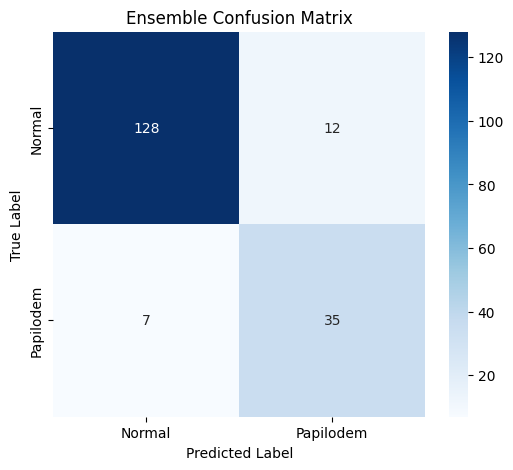

[[128  12]
 [  7  35]]


In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ensemble_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Papilodem"],
    yticklabels=["Normal", "Papilodem"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Confusion Matrix")

plt.show()

print(cm)

**ROC Curve**

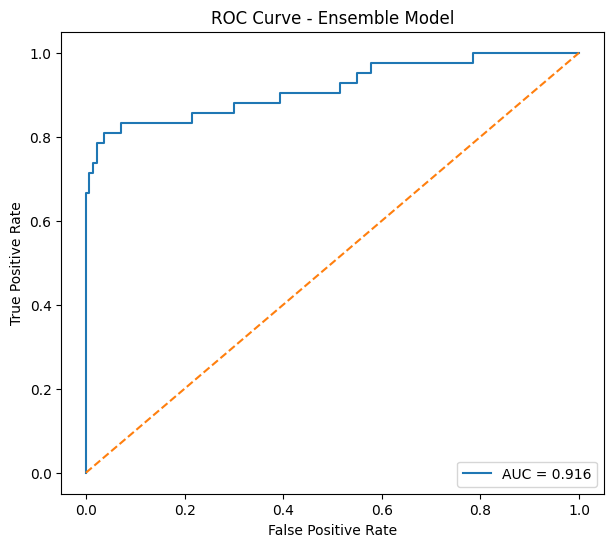

In [29]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    ensemble_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Model")

plt.legend(loc="lower right")

plt.show()

**Precision-Recall Curve**

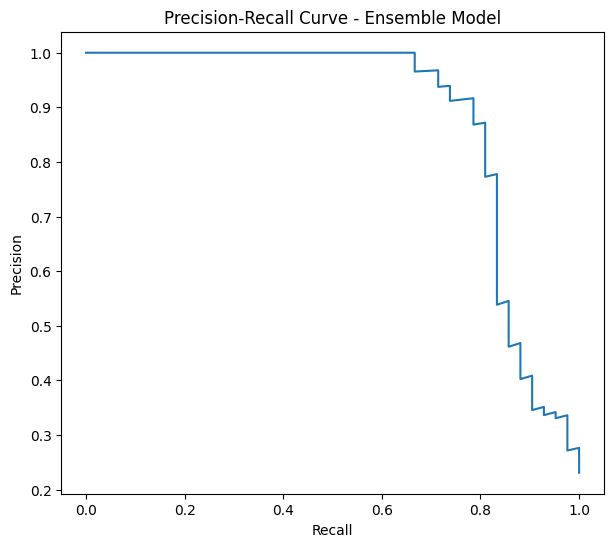

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    ensemble_probs
)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Ensemble Model")

plt.show()

**Calibration Curve**

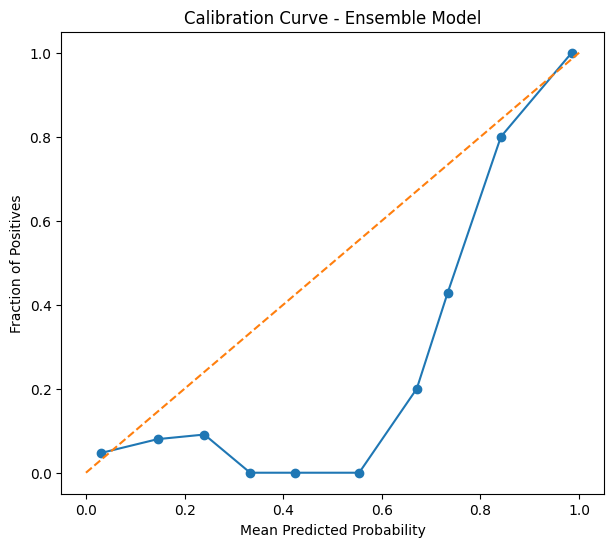

In [31]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    ensemble_probs,
    n_bins=10
)

plt.figure(figsize=(7,6))

plt.plot(prob_pred, prob_true, marker='o')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - Ensemble Model")

plt.show()

**Feature Importance**

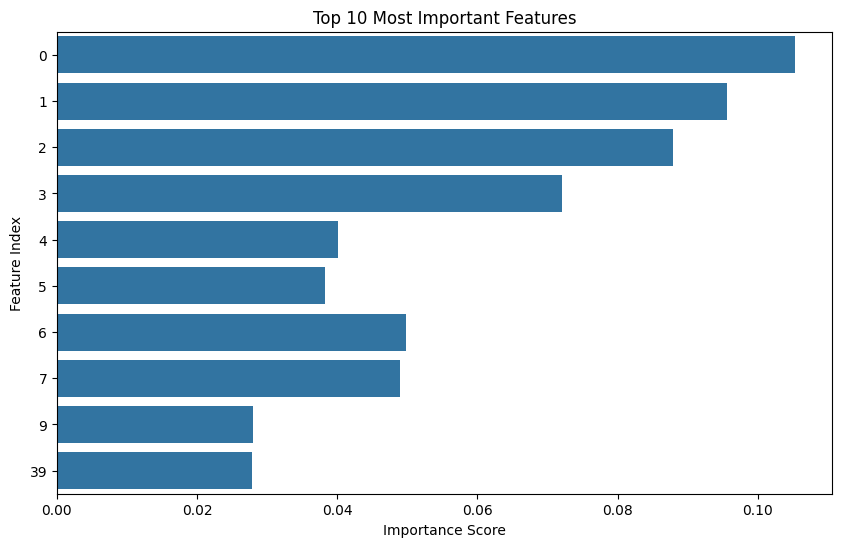

0     0.105329
1     0.095676
2     0.087957
3     0.072132
6     0.049789
7     0.048969
4     0.040128
5     0.038273
9     0.028041
39    0.027785
dtype: float64


In [32]:
feature_importances = pd.Series(
    rf_model.feature_importances_
).sort_values(ascending=False)

top10 = feature_importances.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    orient="h"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature Index")
plt.title("Top 10 Most Important Features")

plt.show()

print(top10)

**Model Comparison**

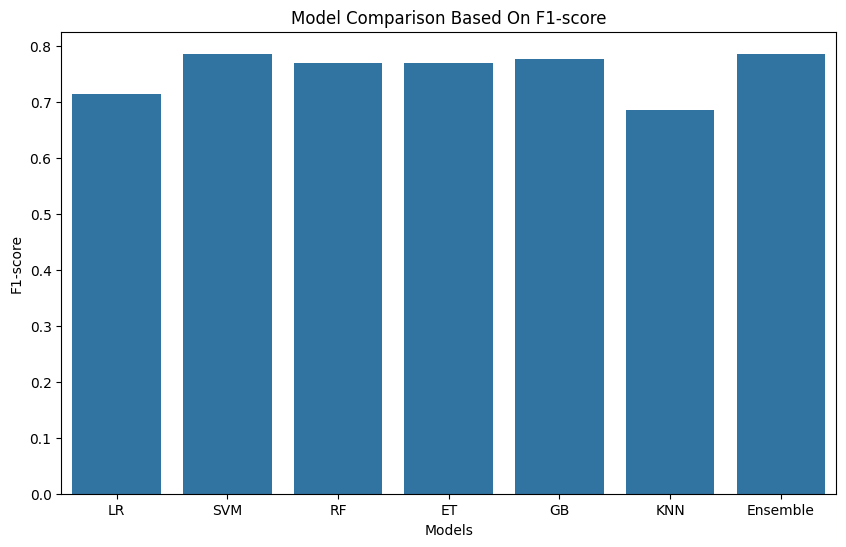

In [33]:
models = [
    "LR",
    "SVM",
    "RF",
    "ET",
    "GB",
    "KNN",
    "Ensemble"
]

f1_scores = [
    0.7143,
    0.7865,
    0.7692,
    0.7692,
    0.7778,
    0.6863,
    0.7865
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=f1_scores
)

plt.ylabel("F1-score")
plt.xlabel("Models")
plt.title("Model Comparison Based On F1-score")

plt.show()

**Friedman Test**

In [34]:
from scipy.stats import friedmanchisquare

lr_scores = [0.7143]
svm_scores = [0.7865]
rf_scores = [0.7692]
et_scores = [0.7692]
gb_scores = [0.7778]
knn_scores = [0.6863]
ensemble_scores = [0.7865]

friedman_result = friedmanchisquare(
    lr_scores,
    svm_scores,
    rf_scores,
    et_scores,
    gb_scores,
    knn_scores,
    ensemble_scores
)

print(friedman_result)

FriedmanchisquareResult(statistic=np.float64(5.999999999999999), pvalue=np.float64(0.42319008112684353))


**Wilcoxon Signed-Rank Test**

In [35]:
from scipy.stats import wilcoxon

model1 = [0.7865]
model2 = [0.6863]

wilcoxon_result = wilcoxon(
    model1,
    model2
)

print(wilcoxon_result)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))


**Optuna Hyperparameter Optimization**

In [36]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.7 MB/s eta 0:00:00


In [37]:
import optuna

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.svm import SVC

def objective(trial):
    C = trial.suggest_float("C", 0.01, 100, log=True)
    gamma = trial.suggest_float("gamma", 0.0001, 1, log=True)

    model = SVC(
        kernel="rbf",
        C=C,
        gamma=gamma,
        probability=True,
        random_state=42
    )

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in cv.split(
        X_train_selected,
        y_train,
        groups_train
    ):
        X_tr = X_train_selected.iloc[train_idx]
        X_va = X_train_selected.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_va = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        preds = model.predict(X_va)

        score = f1_score(
            y_va,
            preds,
            average="macro"
        )

        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=50
)

print("Best Macro-F1:", study.best_value)
print("Best Parameters:", study.best_params)

[I 2026-05-26 23:49:42,838] A new study created in memory with name: no-name-4803d656-264c-423c-a640-ab64e8e3b6f9
[I 2026-05-26 23:49:44,100] Trial 0 finished with value: 0.40248366013071896 and parameters: {'C': 0.31489116479568624, 'gamma': 0.6351221010640696}. Best is trial 0 with value: 0.40248366013071896.
[I 2026-05-26 23:49:44,613] Trial 1 finished with value: 0.9041983196119483 and parameters: {'C': 8.471801418819979, 'gamma': 0.024810409748678097}. Best is trial 1 with value: 0.9041983196119483.
[I 2026-05-26 23:49:45,377] Trial 2 finished with value: 0.40248366013071896 and parameters: {'C': 0.04207988669606638, 'gamma': 0.0004207053950287938}. Best is trial 1 with value: 0.9041983196119483.
[I 2026-05-26 23:49:46,520] Trial 3 finished with value: 0.40248366013071896 and parameters: {'C': 0.017073967431528128, 'gamma': 0.29154431891537513}. Best is trial 1 with value: 0.9041983196119483.
[I 2026-05-26 23:49:47,124] Trial 4 finished with value: 0.887342198348003 and parameters

Best Macro-F1: 0.9186217807053303
Best Parameters: {'C': 8.25010301746122, 'gamma': 0.002061516808799146}
